# ENEM 2019 e 2023 (RS e SP)

**Fase 2 — Compreensão dos Dados**

Este notebook compara os anos de **2019 (pré-pandemia) e 2023**, com recorte para os estados do Rio Grande do Sul e São Paulo.

Carregamento da estrutura dos dois datasets, identificação de valores faltantes ou nulos, aplicação de filtro de presença (participantes que fizeram as duas provas) e uma visualização do panorama geral por ano e estado.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

#carregamento dos datasets
df_2019 = pd.read_parquet('../../dados-processados/enem2019_RS_SP.parquet')
df_2023 = pd.read_parquet('../../dados-processados/enem2023_RS_SP.parquet')

#juncao dos dois datasets
df = pd.concat([df_2019, df_2023], ignore_index=True)

print(f"2019: {len(df_2019):,} participantes")
print(f"2023: {len(df_2023):,} participantes")
print(f"Total: {len(df):,} participantes")
print(f"Colunas: {df.shape[1]}")

2019: 1,034,459 participantes
2023: 750,686 participantes
Total: 1,785,145 participantes
Colunas: 20


In [2]:
#visao geral do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1785145 entries, 0 to 1785144
Data columns (total 20 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   NU_INSCRICAO            int64  
 1   TP_FAIXA_ETARIA         int64  
 2   TP_SEXO                 str    
 3   TP_COR_RACA             int64  
 4   TP_ESCOLA               int64  
 5   TP_DEPENDENCIA_ADM_ESC  float64
 6   SG_UF_PROVA             str    
 7   TP_PRESENCA_CN          int64  
 8   TP_PRESENCA_CH          int64  
 9   TP_PRESENCA_LC          int64  
 10  TP_PRESENCA_MT          int64  
 11  NU_NOTA_CN              float64
 12  NU_NOTA_CH              float64
 13  NU_NOTA_LC              float64
 14  NU_NOTA_MT              float64
 15  NU_NOTA_REDACAO         float64
 16  Q001                    str    
 17  Q002                    str    
 18  Q006                    str    
 19  NU_ANO                  int64  
dtypes: float64(6), int64(9), str(5)
memory usage: 282.6 MB


In [3]:
#primeiras linhas do dataset
df.head()

,NU_INSCRICAO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ESCOLA,TP_DEPENDENCIA_ADM_ESC,SG_UF_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q001,Q002,Q006,NU_ANO
0,190001595656,13,M,3,1,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B,B,A,2019
1,190001595657,5,M,3,1,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,E,B,D,2019
2,190001592264,5,F,1,1,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,B,C,C,2019
3,190001592266,2,M,1,2,NaN,SP,1,1,1,1,543.9,548.1,502.5,480.7,400.0,E,E,F,2019
4,190001592265,6,F,1,1,NaN,SP,0,0,0,0,NaN,NaN,NaN,NaN,NaN,D,D,C,2019


In [4]:
#identificando colunas com valores faltantes
faltantes = df.isna().sum()
percentual = (faltantes / len(df) * 100).round(1)
tabela_faltantes = pd.DataFrame({
    'faltantes': faltantes,
    'percentual_%': percentual
}).sort_values('faltantes', ascending=False)

tabela_faltantes

,faltantes,percentual_%
TP_DEPENDENCIA_ADM_ESC,1292242,72.4
NU_NOTA_CN,522028,29.2
NU_NOTA_MT,522028,29.2
NU_NOTA_CH,445538,25.0
NU_NOTA_REDACAO,445538,25.0
NU_NOTA_LC,445538,25.0
TP_FAIXA_ETARIA,0,0.0
NU_INSCRICAO,0,0.0
TP_COR_RACA,0,0.0
TP_SEXO,0,0.0


Filtro de presença

Os faltantes nas colunas de nota correspondem a participantes que não fizeram a prova, ou seja, faltaram ou foram eliminados. 

A variável `TP_PRESENCA_*` indica isso:

- `0` = Faltou
- `1` = Presente
- `2` = Eliminado

Vamos considerar apenas quem estece presente nos dois dias de prova.

In [5]:
#distribuição de presença
print("Presença em Ciências da Natureza (dia 1):")
print(df['TP_PRESENCA_CN'].value_counts(normalize=True).round(3))
print("\nPresença em Matemática (dia 2):")
print(df['TP_PRESENCA_MT'].value_counts(normalize=True).round(3))

Presença em Ciências da Natureza (dia 1):
TP_PRESENCA_CN
1    0.708
0    0.292
2    0.000
Name: proportion, dtype: float64

Presença em Matemática (dia 2):
TP_PRESENCA_MT
1    0.708
0    0.292
2    0.000
Name: proportion, dtype: float64


In [7]:
#aplicacao do filtro: presente (=1) nos dois dias, em todas as áreas
presente_2_dias = (
    (df['TP_PRESENCA_CN'] == 1) &
    (df['TP_PRESENCA_CH'] == 1) &
    (df['TP_PRESENCA_LC'] == 1) &
    (df['TP_PRESENCA_MT'] == 1)
)

df_pres = df[presente_2_dias].copy()

#adiciona uma coluna com a nota média (média das 5 áreas)
areas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']
df_pres['NOTA_MEDIA'] = df_pres[areas].mean(axis=1)

print(f"Total de inscritos: {len(df):,}")
print(f"Presentes nos 2 dias: {len(df_pres):,} ({len(df_pres)/len(df)*100:.1f}%)")

Total de inscritos: 1,785,145
Presentes nos 2 dias: 1,258,720 (70.5%)


In [8]:
#panorama por ano e estados dos participantes presentes nos 2 dias
tabela = pd.crosstab(df_pres['NU_ANO'], df_pres['SG_UF_PROVA'], margins=True, margins_name='Total')
print("Participantes presentes nos 2 dias por ano e estado:\n")
print(tabela)

Participantes presentes nos 2 dias por ano e estado:

SG_UF_PROVA      RS      SP    Total
NU_ANO                              
2019         155823  582682   738505
2023         110735  409480   520215
Total        266558  992162  1258720


In [9]:
#media de nota por ano e estado
df_pres.groupby(['NU_ANO', 'SG_UF_PROVA'])['NOTA_MEDIA'].agg(['mean', 'median', 'std', 'count']).round(1)

mean  median   std   count
NU_ANO SG_UF_PROVA                             
2019   RS           535.6   530.1  78.1  155823
       SP           543.6   538.9  82.1  582682
2023   RS           557.6   556.5  89.2  110735
       SP           564.9   565.0  88.5  409480

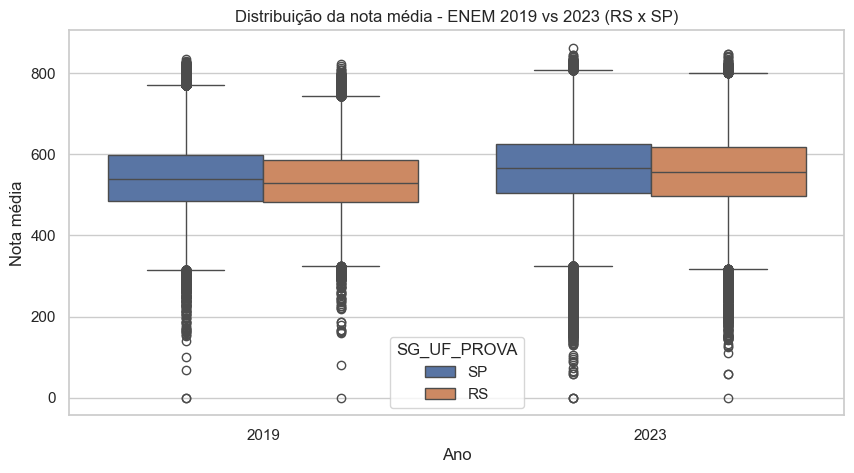

In [10]:
#distribuição da nota media por ano e estado
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_pres, x='NU_ANO', y='NOTA_MEDIA', hue='SG_UF_PROVA', ax=ax)
ax.set_title('Distribuição da nota média - ENEM 2019 vs 2023 (RS x SP)')
ax.set_xlabel('Ano')
ax.set_ylabel('Nota média')
plt.show()